In [29]:
import os
from concurrent.futures import ThreadPoolExecutor

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
os.environ.setdefault("OMP_NUM_THREADS", "1")

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from ensemble_vae import (
    VAE, GaussianDecoder, GaussianEncoder, GaussianPrior,
    pullback_metric, plot_metric, PLcurve, curve_energy, connecting_geodesic,
)
from tqdm import tqdm


def pick_device():
    if torch.cuda.is_available():
        return "cuda"
    if hasattr(torch, "xpu") and torch.xpu.is_available():
        try:
            x = torch.randn(8, 8, device="xpu")
            _ = (x @ x).sum().item()
            return "xpu"
        except Exception:
            return "cpu"
    return "cpu"


device = pick_device()
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass
print("Device:", device)


Device: xpu


## Architecture

In [30]:
M = 2  # latent dim

def encoder():
    return nn.Sequential(
        nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.Softmax(), nn.BatchNorm2d(16),
        nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.Softmax(), nn.BatchNorm2d(32),
        nn.Conv2d(32, 32, 3, stride=2, padding=1),
        nn.Flatten(),
        nn.Linear(512, 2 * M),
    )

def decoder():
    return nn.Sequential(
        nn.Linear(M, 512),
        nn.Unflatten(-1, (32, 4, 4)),
        nn.Softmax(), nn.BatchNorm2d(32),
        nn.ConvTranspose2d(32, 32, 3, stride=2, padding=1, output_padding=0),
        nn.Softmax(), nn.BatchNorm2d(32),   
        nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
        nn.Softmax(), nn.BatchNorm2d(16),
        nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
    )

def vae():
    return VAE(GaussianPrior(M), GaussianDecoder(decoder()), GaussianEncoder(encoder())).to(device)

## Data

In [31]:
def subsample(data, targets, num_data, num_classes):
    idx = targets < num_classes
    new_data    = data[idx][:num_data].unsqueeze(1).to(torch.float32) / 255
    new_targets = targets[idx][:num_data]
    return torch.utils.data.TensorDataset(new_data, new_targets)

NUM_TRAIN_DATA = 2048
NUM_CLASSES    = 3
BATCH_SIZE     = 32

train_tensors = datasets.MNIST('data/', train=True,  download=True, transform=transforms.ToTensor())
test_tensors  = datasets.MNIST('data/', train=False, download=True, transform=transforms.ToTensor())

train_data = subsample(train_tensors.data, train_tensors.targets, NUM_TRAIN_DATA, NUM_CLASSES)
test_data  = subsample(test_tensors.data,  test_tensors.targets,  NUM_TRAIN_DATA, NUM_CLASSES)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_data)} | Test: {len(test_data)}')

Train: 2048 | Test: 2048


In [32]:
def noise(x, std=0.05):
    return torch.clamp(x + std * torch.randn_like(x), 0.0, 1.0)


def train_vae(model, optimizer, data_loader, epochs):
    """Thin wrapper around ensemble_vae.train with safe fallback on backend failure."""
    from ensemble_vae import train

    try:
        train(model, optimizer, data_loader, epochs, device)
    except RuntimeError as e:
        msg = str(e).lower()
        backend_issue = ("xpu" in msg) or ("oneapi" in msg) or ("dnnl" in msg) or ("out of memory" in msg)
        if device == "xpu" and backend_issue:
            print("XPU backend failed during training, retrying on CPU...")
            model_cpu = model.to("cpu")
            optimizer_cpu = torch.optim.Adam(model_cpu.parameters(), lr=optimizer.param_groups[0]["lr"])
            train(model_cpu, optimizer_cpu, data_loader, epochs, "cpu")
            return model_cpu
        raise

    return model


def train_and_save_vae(path, epochs=50):
    os.makedirs(path, exist_ok=True)
    model = vae()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    model = train_vae(model, optimizer, train_loader, epochs)
    torch.save(model.state_dict(), f"{path}/model.pt")
    return model


def load_vae(path):
    model = vae()
    model.load_state_dict(torch.load(f"{path}/model.pt", map_location=device))
    model.eval()
    return model


@torch.no_grad()
def encode_dataset(model, loader):
    """Return (latent means, labels) for an entire dataset."""
    zs, ys = [], []
    model.eval()
    for x, y in loader:
        zs.append(model.encoder(x.to(next(model.parameters()).device)).mean.cpu())
        ys.append(y)
    return torch.cat(zs), torch.cat(ys)

## Part A

Single VAE with ELBO loss:

$$\mathcal{L} = \mathbb{E}_{q_\phi(z|x)}[\log p_\theta(x|z)] - D_\mathrm{KL}(q_\phi(z|x) \| p(z))$$

In [33]:
FOLDER_A = 'experiment_single'
EPOCHS_A = 100

if not os.path.exists(f'{FOLDER_A}/model.pt'):
    print('Training single VAE...')
    if device == 'cuda':
        torch.cuda.empty_cache()
    model_A = train_and_save_vae(FOLDER_A, epochs=EPOCHS_A)
else:
    print('Loading existing model...')
    model_A = load_vae(FOLDER_A)

Loading existing model...


In [34]:
# Pullback metric: G_ij(z) = sum_n (df_n/dz_i)(df_n/dz_j)
def make_metric(model):
    net = model.decoder.decoder_net
    def metric(z):
        z_leaf = z.detach().requires_grad_(True)
        out    = net(z_leaf)
        grads  = torch.autograd.grad(out.sum(), z_leaf)[0].detach()
        return torch.einsum('ni,nj->nij', grads, grads).cpu()
    return metric


def compute_geodesic(model, z0, z1, num_t=20, lr=5e-3, n_steps=300):
    """Minimise curve energy under the pullback metric via Adam."""
    metric = make_metric(model)
    c = PLcurve(z0.cpu(), z1.cpu(), num_t)
    connecting_geodesic('Adam', metric, c, lr=lr, max_iter=n_steps)
    return c.points().detach().cpu()


In [35]:
z_test, y_test = encode_dataset(model_A, test_loader)
print(f'z_test: {z_test.shape}, y_test: {y_test.shape}')

NUM_CURVES      = 50
NUM_T           = 20
GEO_LR          = 1e-3
GEO_STEPS       = 300
NUM_GEO_WORKERS = 24

torch.manual_seed(42)
np.random.seed(42)
n_test    = z_test.shape[0]
idx_pairs = [(np.random.randint(n_test), np.random.randint(n_test))
             for _ in range(NUM_CURVES)]


z_test: torch.Size([2048, 2]), y_test: torch.Size([2048])


In [36]:
model_A.to('cpu').requires_grad_(False)

def _geo_A_job(pair):
    i, j = pair
    return compute_geodesic(
        model_A,
        z_test[i].cpu(),
        z_test[j].cpu(),
        num_t=NUM_T, lr=GEO_LR, n_steps=GEO_STEPS,
    ).numpy()

with ThreadPoolExecutor(max_workers=NUM_GEO_WORKERS) as pool:
    geodesics_A = list(tqdm(
        pool.map(_geo_A_job, idx_pairs),
        total=len(idx_pairs),
        desc='Geodesics (Part A)',
    ))


Geodesics (Part A): 100%|██████████| 50/50 [00:14<00:00,  3.41it/s]


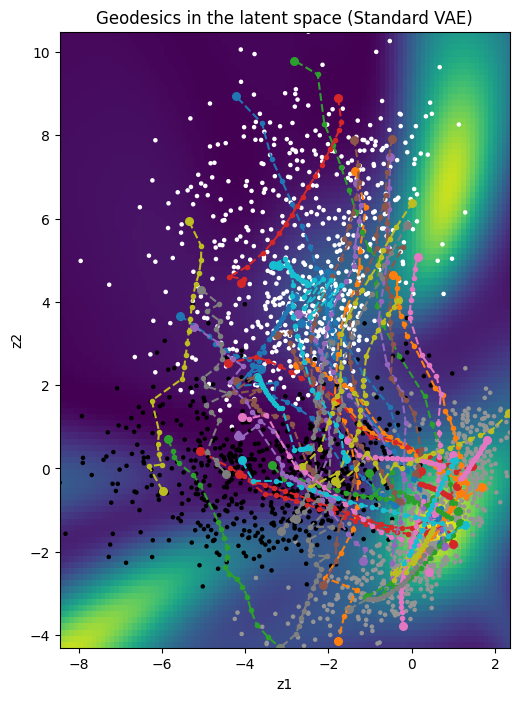

In [50]:
z_np  = z_test.numpy()
y_np  = y_test.numpy()
z1_min, z1_max = z_np[:, 0].min(), z_np[:, 0].max()
z2_min, z2_max = z_np[:, 1].min(), z_np[:, 1].max()

plt.figure(figsize=(8, 8))
scatter = plt.scatter(z_np[:, 0], z_np[:, 1], c=y_np, cmap="Grays", s=5)
plt.xlabel('z1')
plt.ylabel('z2')

metric_A = make_metric(model_A)
plot_metric(
    metric_A,
    torch.linspace(float(z1_min), float(z1_max), 100),
    torch.linspace(float(z2_min), float(z2_max), 100),
)

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CURVES))
for i, curve in enumerate(geodesics_A):
    col_cur = colors[i]
    plt.plot(curve[:, 0], curve[:, 1], '--o', color=col_cur, markersize=3)
    plt.scatter(curve[[0, -1], 0], curve[[0, -1], 1], color=col_cur, s=30)

plt.title('Geodesics in the latent space (Standard VAE)')
plt.savefig('geodesics_partA.png', dpi=100, bbox_inches='tight')
plt.show()


## Part B

Ensemble of $K$ independent decoders with a shared encoder.

In [38]:
class EnsembleVAE(nn.Module):
    """
    Wraps GaussianPrior / GaussianEncoder (from ensemble_vae.py) with
    multiple GaussianDecoder ensemble members.
    """
    def __init__(self, prior, encoder, decoders):
        super().__init__()
        self.prior    = prior
        self.encoder  = encoder
        self.decoders = nn.ModuleList(decoders)

    def elbo(self, x, decoder_idx=0):
        q = self.encoder(x)
        z = q.rsample()
        dec = self.decoders[decoder_idx]
        return torch.mean(
            dec(z).log_prob(x) - q.log_prob(z) + self.prior().log_prob(z)
        )

    def forward(self, x, decoder_idx=0):
        return -self.elbo(x, decoder_idx)


def new_ensemble(num_decoders, shared_encoder=None):
    """If shared_encoder is given it is used as-is (not copied); otherwise a fresh one is created."""
    enc = shared_encoder if shared_encoder is not None else GaussianEncoder(encoder())
    return EnsembleVAE(
        GaussianPrior(M),
        enc,
        [GaussianDecoder(decoder()) for _ in range(num_decoders)],
    ).to(device)


In [39]:
def train_ensemble(path, num_decoders, epochs_per_decoder=50, shared_encoder=None):
    """Train an EnsembleVAE with `num_decoders` decoders sequentially."""
    os.makedirs(path, exist_ok=True)
    ensemble = new_ensemble(num_decoders, shared_encoder=shared_encoder)

    if shared_encoder is not None:
        for p in ensemble.encoder.parameters():
            p.requires_grad_(False)

    for k in range(num_decoders):
        print(f'  decoder {k+1}/{num_decoders}')
        params = list(ensemble.decoders[k].parameters())
        if shared_encoder is None:
            params += list(ensemble.encoder.parameters())
        optimizer = torch.optim.Adam(params, lr=1e-3)
        num_steps = len(train_loader) * epochs_per_decoder

        with tqdm(range(num_steps), leave=False) as pbar:
            for step in pbar:
                x = next(iter(train_loader))[0]
                x = noise(x.to(device))
                optimizer.zero_grad()
                loss = ensemble(x, decoder_idx=k)
                loss.backward()
                optimizer.step()
                if step % 5 == 0:
                    pbar.set_description(f'loss={loss.item():.1f}')

    torch.save(ensemble.state_dict(), f'{path}/ensemble.pt')
    return ensemble


def load_ensemble(path, num_decoders, shared_encoder=None):
    ensemble = new_ensemble(num_decoders)
    ensemble.load_state_dict(torch.load(f'{path}/ensemble.pt', map_location=device))
    if shared_encoder is not None:
        ensemble.encoder = shared_encoder
    ensemble.eval()
    return ensemble


## Curve Energy

Geodesic minimises the MC-estimated image-space curve energy:

$$\mathcal{E}[c] = \mathbb{E}_{l,k \sim \mathcal{U}}\!\left[\sum_{t=1}^{T-1}\|f_l(c_t)-f_k(c_{t+1})\|^2\right]$$

In [40]:
def ensemble_curve_energy(ensemble, curve_points, num_mc=10, n_active=None):
    """
    MC approximation of the model-average curve energy (project Eq. 1).

    Only the first n_active decoders are used (all if n_active is None).
    l, k are drawn uniformly from those n_active decoders.
    """
    decoders = list(ensemble.decoders) if n_active is None else list(ensemble.decoders)[:n_active]
    n_dec  = len(decoders)
    energy = torch.tensor(0.0, device=curve_points.device)

    for _ in range(num_mc):
        l = torch.randint(n_dec, (1,)).item()
        k = torch.randint(n_dec, (1,)).item()
        f_l = decoders[l].decoder_net(curve_points[:-1])  # (N, 1, 28, 28)
        f_k = decoders[k].decoder_net(curve_points[1:])   # (N, 1, 28, 28)
        energy = energy + ((f_l - f_k) ** 2).sum(dim=(1, 2, 3)).sum()

    return energy / num_mc


def compute_ensemble_geodesic(ensemble, z0, z1, num_t=20, lr=5e-3,
                               n_steps=300, num_mc=10, n_active=None):
    """Same optimisation loop as Part A but using the ensemble energy."""
    t        = torch.linspace(0, 1, num_t, device=z0.device)
    init     = z0[None] + t[:, None] * (z1 - z0)[None]
    interior = init[1:-1].clone().detach().requires_grad_(True)

    optimizer = torch.optim.Adam([interior], lr=lr)

    for _ in range(n_steps):
        optimizer.zero_grad()
        curve = torch.cat([z0[None], interior, z1[None]], dim=0)
        ensemble_curve_energy(ensemble, curve, num_mc=num_mc, n_active=n_active).backward()
        optimizer.step()

    with torch.no_grad():
        curve = torch.cat([z0[None], interior, z1[None]], dim=0)
    return curve.detach()


In [41]:
NUM_RERUNS         = 10
DECODER_SIZES      = [1, 2, 3]
EPOCHS_PER_DECODER = 50
ENSEMBLE_FOLDER    = 'experiments_ensemble_shared'

for n_dec in DECODER_SIZES:
    for run in range(NUM_RERUNS):
        path = f'{ENSEMBLE_FOLDER}/ndec_{n_dec}/run_{run:02d}'
        if not os.path.exists(f'{path}/ensemble.pt'):
            print(f'Training n_dec={n_dec}, run {run+1}/{NUM_RERUNS}...')
            train_ensemble(path, num_decoders=n_dec,
                           epochs_per_decoder=EPOCHS_PER_DECODER,
                           shared_encoder=model_A.encoder)
        else:
            print(f'n_dec={n_dec} run {run+1} already done â€” skipping.')


n_dec=1 run 1 already done â€” skipping.
n_dec=1 run 2 already done â€” skipping.
n_dec=1 run 3 already done â€” skipping.
n_dec=1 run 4 already done â€” skipping.
n_dec=1 run 5 already done â€” skipping.
n_dec=1 run 6 already done â€” skipping.
n_dec=1 run 7 already done â€” skipping.
n_dec=1 run 8 already done â€” skipping.
n_dec=1 run 9 already done â€” skipping.
n_dec=1 run 10 already done â€” skipping.
n_dec=2 run 1 already done â€” skipping.
n_dec=2 run 2 already done â€” skipping.
n_dec=2 run 3 already done â€” skipping.
n_dec=2 run 4 already done â€” skipping.
n_dec=2 run 5 already done â€” skipping.
n_dec=2 run 6 already done â€” skipping.
n_dec=2 run 7 already done â€” skipping.
n_dec=2 run 8 already done â€” skipping.
n_dec=2 run 9 already done â€” skipping.
n_dec=2 run 10 already done â€” skipping.
n_dec=3 run 1 already done â€” skipping.
n_dec=3 run 2 already done â€” skipping.
n_dec=3 run 3 already done â€” skipping.
n_dec=3 run 4 already done â€” skipping.
n_dec=3 run 5 

## Coefficient of Variation

$$\mathrm{CoV}(d) = \dfrac{\sigma_\mathrm{run}(d)}{\mu_\mathrm{run}(d)}$$

Mean CoV across pairs — lower is more stable across decoder random seeds.

In [42]:
NUM_PAIRS_COV = 10
all_x         = torch.stack([x for x, _ in test_data])
pair_images   = [(all_x[i], all_x[j]) for i, j in idx_pairs[:NUM_PAIRS_COV]]
print(f'Using {NUM_PAIRS_COV} image pairs for CoV evaluation.')


Using 10 image pairs for CoV evaluation.


In [43]:
def riemannian_length(ensemble, curve):
    # Image-space arc-length averaged over decoders
    n_dec  = len(ensemble.decoders)
    energy = torch.tensor(0.0)
    with torch.no_grad():
        for dec in ensemble.decoders:
            f_left  = dec.decoder_net(curve[:-1])
            f_right = dec.decoder_net(curve[1:])
            energy  = energy + ((f_left - f_right) ** 2).sum(dim=(1, 2, 3)).sum()
    return (energy / n_dec).sqrt().item()


def _cov_pair_job(args):
    ensemble, xi, xj = args
    with torch.no_grad():
        zi = ensemble.encoder(xi.unsqueeze(0)).mean.squeeze(0)
        zj = ensemble.encoder(xj.unsqueeze(0)).mean.squeeze(0)
    euc  = (zi - zj).norm().item()
    curve = compute_ensemble_geodesic(
        ensemble, zi, zj,
        num_t=NUM_T, lr=GEO_LR, n_steps=GEO_STEPS, num_mc=5,
    )
    return euc, riemannian_length(ensemble, curve)


euclidean_distances = {k: [] for k in DECODER_SIZES}
geodesic_distances  = {k: [] for k in DECODER_SIZES}

for n_dec in DECODER_SIZES:
    print(f'\n--- n_dec = {n_dec} ---')
    for run in tqdm(range(NUM_RERUNS), desc=f'n_dec={n_dec}'):
        path     = f'{ENSEMBLE_FOLDER}/ndec_{n_dec}/run_{run:02d}'
        ensemble = load_ensemble(path, num_decoders=n_dec, shared_encoder=model_A.encoder)
        ensemble.to('cpu').requires_grad_(False)

        jobs = [(ensemble, xi.cpu(), xj.cpu()) for xi, xj in pair_images]
        with ThreadPoolExecutor(max_workers=NUM_GEO_WORKERS) as pool:
            results = list(pool.map(_cov_pair_job, jobs))

        euclidean_distances[n_dec].append([r[0] for r in results])
        geodesic_distances[n_dec].append([r[1] for r in results])

print('\nDone.')



--- n_dec = 1 ---


n_dec=1: 100%|██████████| 10/10 [02:26<00:00, 14.61s/it]



--- n_dec = 2 ---


n_dec=2: 100%|██████████| 10/10 [02:27<00:00, 14.76s/it]



--- n_dec = 3 ---


n_dec=3: 100%|██████████| 10/10 [02:34<00:00, 15.46s/it]


Done.


n_dec=1  CoV Euclidean=0.0000  CoV Geodesic=0.0339
n_dec=2  CoV Euclidean=0.0000  CoV Geodesic=0.0292
n_dec=3  CoV Euclidean=0.0000  CoV Geodesic=0.0200


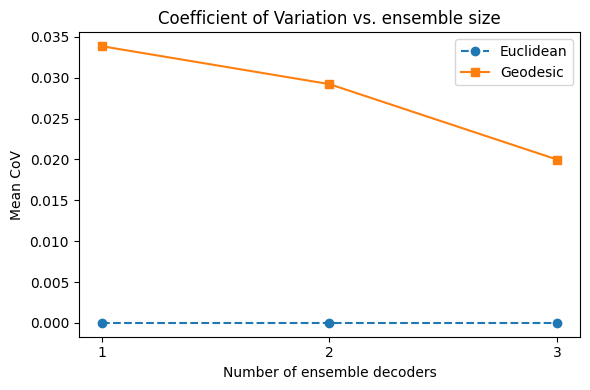

In [44]:
def mean_cov(distances_dict):
    """CoV averaged across pairs: std(d) / mean(d)."""
    result = {}
    for n_dec, runs in distances_dict.items():
        arr = np.array(runs)
        cov = arr.std(axis=0) / (arr.mean(axis=0) + 1e-8)
        result[n_dec] = cov.mean()
    return result

cov_euc = mean_cov(euclidean_distances)
cov_geo = mean_cov(geodesic_distances)

for k in DECODER_SIZES:
    print(f'n_dec={k}  CoV Euclidean={cov_euc[k]:.4f}  CoV Geodesic={cov_geo[k]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(DECODER_SIZES, [cov_euc[k] for k in DECODER_SIZES],
        'o--', label='Euclidean', color='tab:blue')
ax.plot(DECODER_SIZES, [cov_geo[k] for k in DECODER_SIZES],
        's-',  label='Geodesic',  color='tab:orange')
ax.set_xlabel('Number of ensemble decoders')
ax.set_ylabel('Mean CoV')
ax.set_title('Coefficient of Variation vs. ensemble size')
ax.set_xticks(DECODER_SIZES)
ax.legend()
plt.tight_layout()
plt.savefig('cov_plot.png', dpi=150)
plt.show()


## Geodesics (Part B)

In [45]:
MAX_DECODERS = max(DECODER_SIZES)
ensemble_rep = load_ensemble(
    f'{ENSEMBLE_FOLDER}/ndec_{MAX_DECODERS}/run_00',
    num_decoders=MAX_DECODERS,
    shared_encoder=model_A.encoder,
)
ensemble_rep.to('cpu').requires_grad_(False)

def _geo_B_job(pair):
    i, j = pair
    return compute_ensemble_geodesic(
        ensemble_rep,
        z_test[i].cpu(),
        z_test[j].cpu(),
        num_t=NUM_T, lr=GEO_LR, n_steps=GEO_STEPS,
    ).cpu().numpy()

with ThreadPoolExecutor(max_workers=NUM_GEO_WORKERS) as pool:
    geodesics_B = list(tqdm(
        pool.map(_geo_B_job, idx_pairs),
        total=len(idx_pairs),
        desc='Ensemble geodesics (Part B)',
    ))

# Pullback metric averaged over decoders: G(z) = mean_k J_k^T J_k
def make_ensemble_metric(ens):
    nets = [dec.decoder_net for dec in ens.decoders]
    def metric(z):
        M_sum = None
        for net in nets:
            z_leaf = z.detach().requires_grad_(True)
            out    = net(z_leaf)
            g      = torch.autograd.grad(out.sum(), z_leaf)[0].detach()
            M_k    = torch.einsum('ni,nj->nij', g, g)
            M_sum  = M_k if M_sum is None else M_sum + M_k
        return (M_sum / len(nets)).cpu()
    return metric


Ensemble geodesics (Part B): 100%|██████████| 50/50 [02:43<00:00,  3.28s/it]


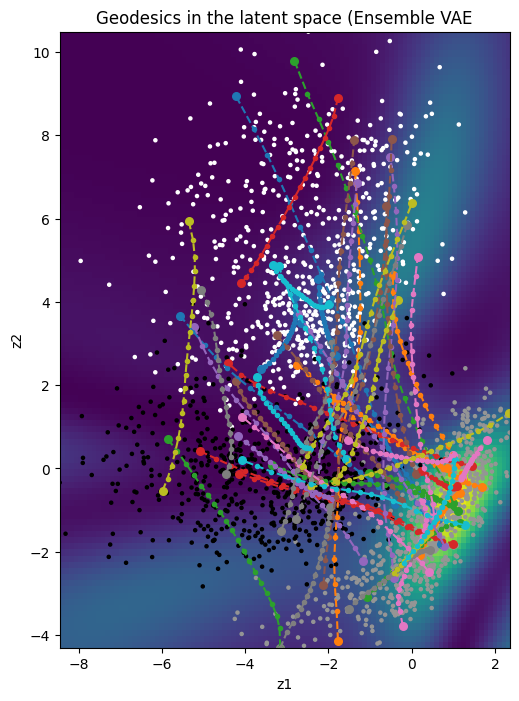

In [49]:
plt.figure(figsize=(8, 8))
scatter = plt.scatter(z_np[:, 0], z_np[:, 1], c=y_np, cmap="Grays", s=5)
plt.xlabel('z1')
plt.ylabel('z2')

plot_metric(
    make_ensemble_metric(ensemble_rep),
    torch.linspace(float(z1_min), float(z1_max), 100),
    torch.linspace(float(z2_min), float(z2_max), 100),
)

colors = plt.cm.tab10(np.linspace(0, 1, NUM_CURVES))
for i, curve in enumerate(geodesics_B):
    col_cur = colors[i]
    plt.plot(curve[:, 0], curve[:, 1], '--o', color=col_cur, markersize=3)
    plt.scatter(curve[[0, -1], 0], curve[[0, -1], 1], color=col_cur, s=30)

plt.title(f'Geodesics in the latent space (Ensemble VAE')
plt.savefig('geodesics_partB.png', dpi=100, bbox_inches='tight')
plt.show()
